In [1]:
## XGBoost Classifier

In [3]:
##1. Data Loading and Preprocessing:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv(r"C:\Users\mohan\Documents\DAP\fraudTest_feature_engineered1.csv")

# Features and target
X = df.drop(columns=['is_fraud'])
y = df['is_fraud']

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y) 

In [4]:
##2. Model Initialization and Training:
from xgboost import XGBClassifier

# Initialize and train XGBoost model
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model.fit(X_train, y_train) 

C:\Users\mohan\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:02:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [5]:
##3. Making Predictions
# Make predictions on the test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probabilities for ROC AUC


In [7]:
##4. Model Evaluation - Accuracy:
from sklearn.metrics import accuracy_score

# Accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.998800355094892


In [8]:
##5. Confusion Matrix:
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)



Confusion Matrix:
 [[165999     73]
 [   127    517]]


In [10]:
##6. Classification Report:
from sklearn.metrics import classification_report

# Classification Report
report = classification_report(y_test, y_pred)
print("\nClassification Report:\n", report)



Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    166072
           1       0.88      0.80      0.84       644

    accuracy                           1.00    166716
   macro avg       0.94      0.90      0.92    166716
weighted avg       1.00      1.00      1.00    166716



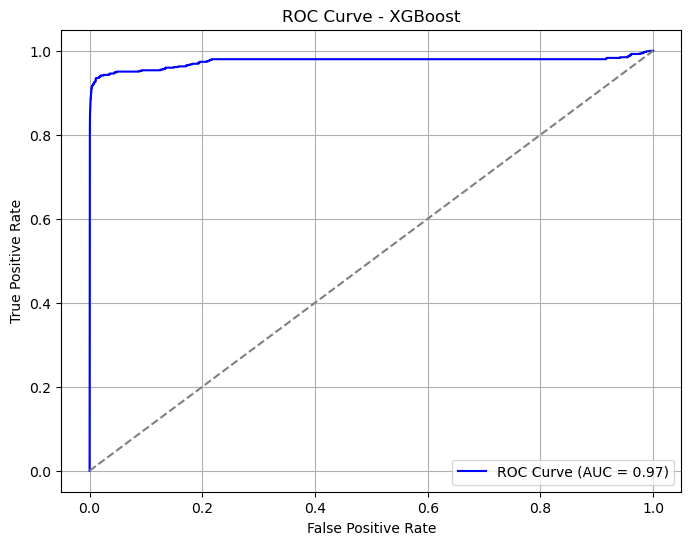


AUC (Area Under the Curve): 0.9748062998717312


In [11]:
##7. ROC Curve and AUC:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve - XGBoost')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Print AUC
print("\nAUC (Area Under the Curve):", roc_auc)


In [12]:
##8. Precision, Recall, and F1-Score:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate Precision, Recall, and F1-Score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print results
print(f"\n Precision: {precision:.2f}")
print(f" Recall: {recall:.2f}")
print(f" F1-Score: {f1:.2f}")




 Precision: 0.88
 Recall: 0.80
 F1-Score: 0.84


In [13]:
##Logistic Regression

In [14]:
##1. Data Loading and Preprocessing
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv(r"C:\Users\mohan\Documents\DAP\fraudTest_feature_engineered1.csv")

# Features and target
X = df.drop(columns=['is_fraud'])
y = df['is_fraud']

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


In [15]:
##2. Model Initialization and Training 
from sklearn.linear_model import LogisticRegression

# Initialize and train Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)


C:\Users\mohan\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

In [16]:
##3. Making Predictions:
# Make predictions on the test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probabilities for ROC AUC


In [18]:
##4. Model Evaluation - Accuracy:
from sklearn.metrics import accuracy_score

# Accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(" Accuracy:", accuracy)


 Accuracy: 0.9961371434055519


In [19]:
##5. Confusion Matrix:
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\n Confusion Matrix:\n", cm)



 Confusion Matrix:
 [[166072      0]
 [   644      0]]


In [20]:
##6. Classification Report:
from sklearn.metrics import classification_report

# Classification Report
report = classification_report(y_test, y_pred)
print("\n Classification Report:\n", report)


C:\Users\mohan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\mohan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))



 Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    166072
           1       0.00      0.00      0.00       644

    accuracy                           1.00    166716
   macro avg       0.50      0.50      0.50    166716
weighted avg       0.99      1.00      0.99    166716



C:\Users\mohan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


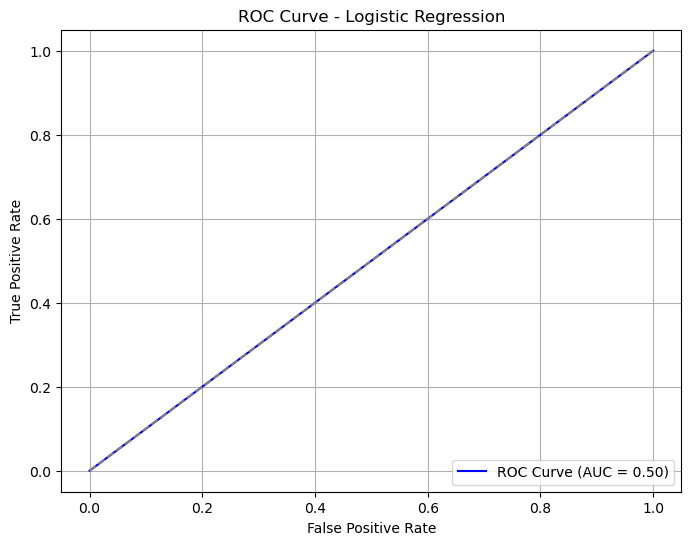


 AUC (Area Under the Curve): 0.5


In [22]:
##7. ROC Curve and AUC:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve - Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Print AUC
print("\n AUC (Area Under the Curve):", roc_auc)


In [23]:
##7. ROC Curve and AUC:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate Precision, Recall, and F1-Score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print results
print(f"\n Precision: {precision:.2f}")
print(f" Recall: {recall:.2f}")
print(f" F1-Score: {f1:.2f}")



 Precision: 0.00
 Recall: 0.00
 F1-Score: 0.00


C:\Users\mohan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [24]:
## Isolation Forest

In [25]:
##1. Data Loading and Preprocessing
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv(r"C:\Users\mohan\Documents\DAP\fraudTest_feature_engineered1.csv")

# Features and target
X = df.drop(columns=['is_fraud'])
y = df['is_fraud']

# Split the dataset into training and test sets (though Isolation Forest doesn't require labels)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


In [26]:
##2. Model Initialization and Training
from sklearn.ensemble import IsolationForest

# Initialize and train Isolation Forest model
model = IsolationForest(n_estimators=100, contamination='auto', random_state=42)
model.fit(X_train)  # Fit only on the features, no need for labels


IsolationForest(random_state=42)

In [27]:
##3. Making Predictions:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Convert the predictions to 0 and 1 (1 for normal, -1 for anomaly)
y_pred = np.where(y_pred == 1, 0, 1)  # 0 for normal, 1 for anomaly (fraud)


In [28]:
##4. Model Evaluation - Accuracy:
from sklearn.metrics import accuracy_score

# Accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(" Accuracy:", accuracy)


 Accuracy: 0.7213644761150699


In [29]:
##5. Confusion Matrix:
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\n Confusion Matrix:\n", cm)



 Confusion Matrix:
 [[119676  46396]
 [    57    587]]


In [31]:
##6. Classification Report:
from sklearn.metrics import classification_report

# Classification Report
report = classification_report(y_test, y_pred)
print("\n Classification Report:\n", report)



 Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.72      0.84    166072
           1       0.01      0.91      0.02       644

    accuracy                           0.72    166716
   macro avg       0.51      0.82      0.43    166716
weighted avg       1.00      0.72      0.83    166716



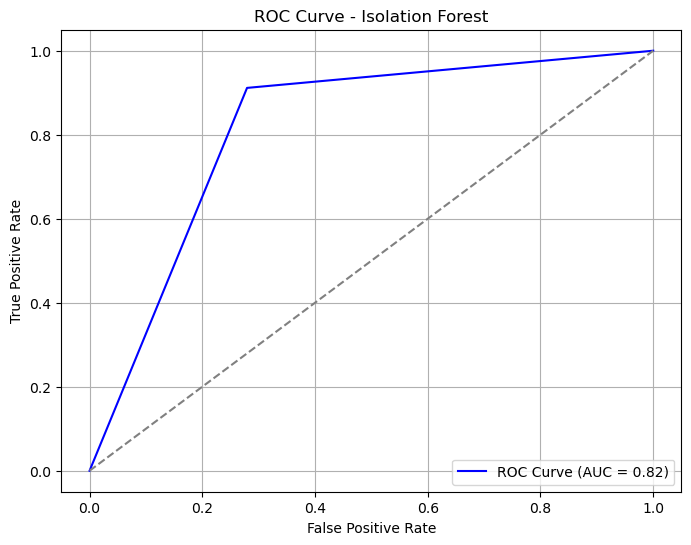


 AUC (Area Under the Curve): 0.8160589405358567


In [33]:
##7. ROC Curve and AUC:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve - Isolation Forest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Print AUC
print("\n AUC (Area Under the Curve):", roc_auc)


In [34]:
##8. Precision, Recall, and F1-Score:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate Precision, Recall, and F1-Score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print results
print(f"\n Precision: {precision:.2f}")
print(f" Recall: {recall:.2f}")
print(f" F1-Score: {f1:.2f}")



 Precision: 0.01
 Recall: 0.91
 F1-Score: 0.02
